# 03 · Panel Construction

**Input :** `data/processed/panel_15min_clean.parquet`  
**Outputs:** `data/processed/panel_hourly.parquet` · `data/processed/panel_daily.parquet`

Steps:
0. Load & inspect clean 15-min panel
1. Sanity-check commute peak pattern
2. Aggregate to hourly panel + time features
3. Aggregate to daily panel + peak counts + peak ratio + season
4. Summary comparison + seasonal time-series plot

## 0. Imports & Config

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

SEASON_MAP = {
    12: "winter", 1: "winter",  2: "winter",
     3: "spring", 4: "spring",  5: "spring",
     6: "summer", 7: "summer",  8: "summer",
     9: "autumn", 10: "autumn", 11: "autumn",
}
SEASON_COLORS = {
    "winter": "#4878d0",
    "spring": "#6acc65",
    "summer": "#d65f5f",
    "autumn": "#e07b39",
}

META_COLS = ["low_coverage", "lon", "lat", "naam",
             "gemeente", "wegnr", "district", "install_date"]

# ── load ──────────────────────────────────────────────────────────────────────
df = pd.read_parquet(PROCESSED / "panel_15min_clean.parquet")

print(f"Shape  : {df.shape}")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\nNaN per column:")
print(df.isnull().sum())
print(f"\nDate range : {df['van'].min()} → {df['van'].max()}")
print(f"Stations   : {df['site ID'].nunique()}")
df.head(3)

Shape  : (15782400, 11)

Dtypes:
site ID                  int32
van             datetime64[ns]
aantal                 float32
low_coverage              bool
lon                    float64
lat                    float64
naam                    object
gemeente                object
wegnr                   object
district                object
install_date    datetime64[ns]
dtype: object

NaN per column:
site ID               0
van                   0
aantal          1406832
low_coverage          0
lon                   0
lat                   0
naam                  0
gemeente         105216
wegnr            210432
district         210432
install_date          0
dtype: int64

Date range : 2023-01-01 00:00:00 → 2025-12-31 23:45:00
Stations   : 150


,site ID,van,aantal,low_coverage,lon,lat,naam,gemeente,wegnr,district,install_date
0,1,2023-01-01 00:00:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
1,1,2023-01-01 00:15:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
2,1,2023-01-01 00:30:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22


## 1. Sanity Check — Commute Pattern Verification

Before building panels we verify the cleaned data still shows the expected commute signature:  
weekdays should have twin peaks (~08:00 and ~17:00), weekends a single midday peak.

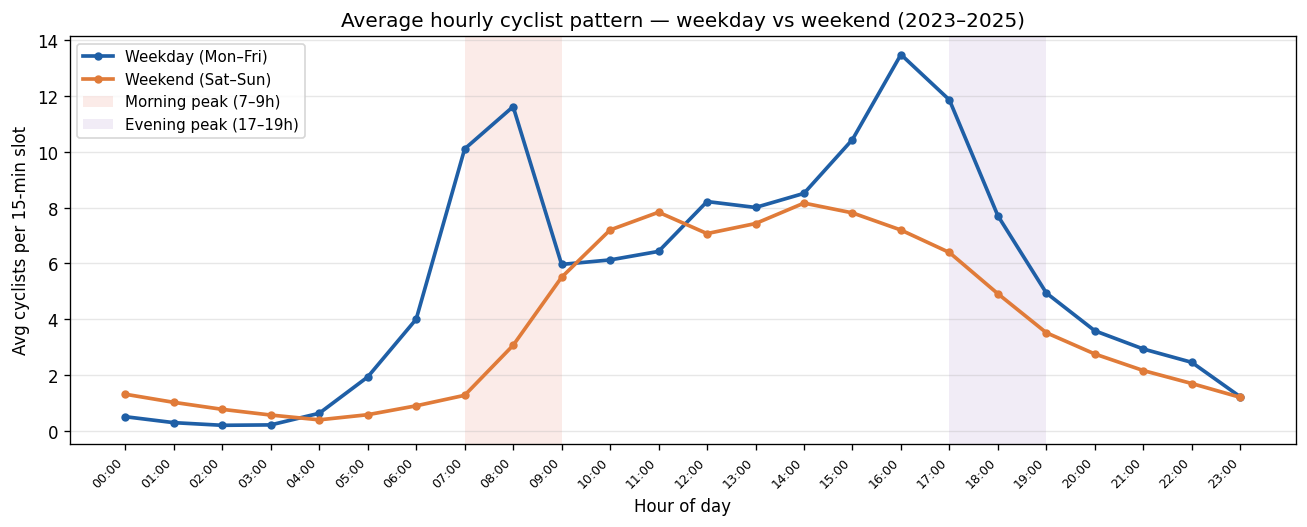

Weekday mean (all hours)         : 5.47
Morning avg (7–9h)  : 9.23  → 1.69x mean
Evening avg (16–18h) : 11.02  → 2.01x mean
Weekend peak hour                : 14:00

✓  Twin peak pattern visible — data looks correct.


In [5]:
df["_hour"]      = df["van"].dt.hour
df["_dayofweek"] = df["van"].dt.dayofweek
df["_is_weekend"]= df["_dayofweek"] >= 5

# filter out low-coverage rows and those with missing counts
good = df[~df["low_coverage"] & df["aantal"].notna()]

# compute average cyclists per hour, split by weekday vs weekend
hourly_avg = (
    good.groupby(["_is_weekend", "_hour"])["aantal"]
    .mean()
    .reset_index(name="avg")
)

# split weekday vs weekend for plotting
weekday = hourly_avg[~hourly_avg["_is_weekend"]].sort_values("_hour")
weekend = hourly_avg[ hourly_avg["_is_weekend"]].sort_values("_hour")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(weekday["_hour"], weekday["avg"],
        color="#1f5fa6", lw=2.2, marker="o", ms=4, label="Weekday (Mon–Fri)")
ax.plot(weekend["_hour"], weekend["avg"],
        color="#e07b39", lw=2.2, marker="o", ms=4, label="Weekend (Sat–Sun)")
ax.axvspan(7,  9,  color="#e25c46", alpha=0.12, lw=0, label="Morning peak (7–9h)")
ax.axvspan(17, 19, color="#9467bd", alpha=0.12, lw=0, label="Evening peak (17–19h)")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)],
                   rotation=45, ha="right", fontsize=7.5)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg cyclists per 15-min slot")
ax.set_title("Average hourly cyclist pattern — weekday vs weekend (2023–2025)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig04_commute_pattern.png", dpi=150)
plt.show()

# compute some key stats to check for expected patterns
wd_mean = weekday["avg"].mean() # overall weekday mean (all hours)
wd_morn = weekday.loc[weekday["_hour"].isin([7, 8, 9]), "avg"].mean() # morning peak (7–9h)
wd_eve  = weekday.loc[weekday["_hour"].isin([16, 17, 18]), "avg"].mean() # evening peak (16–18h)
we_peak = int(weekend.loc[weekend["avg"].idxmax(), "_hour"]) # weekend peak hour

morn_ratio = wd_morn / wd_mean # how much higher is the morning peak vs overall weekday mean?
eve_ratio  = wd_eve  / wd_mean # how much higher is the evening peak vs overall weekday mean?

print(f"Weekday mean (all hours)         : {wd_mean:.2f}")
print(f"Morning avg (7–9h)  : {wd_morn:.2f}  → {morn_ratio:.2f}x mean")
print(f"Evening avg (16–18h) : {wd_eve:.2f}  → {eve_ratio:.2f}x mean")
print(f"Weekend peak hour                : {we_peak:02d}:00")

THRESHOLD = 1.3 # we expect the morning and evening peaks to be at least 30% higher than the overall weekday mean
has_morn = morn_ratio > THRESHOLD
has_eve  = eve_ratio  > THRESHOLD

if has_morn and has_eve:
    print(f"\n✓  Twin peak pattern visible — data looks correct.")
else:
    if not has_morn:
        print(f"\n⚠  WARNING: Morning peak (7–9h) not elevated (ratio={morn_ratio:.2f}, need >{THRESHOLD}).")
    if not has_eve:
        print(f"\n⚠  WARNING: Evening peak (16–18h) not elevated (ratio={eve_ratio:.2f}, need >{THRESHOLD}).")

# drop temp columns
df.drop(columns=["_hour", "_dayofweek", "_is_weekend"], inplace=True)

Commute peaks (weekday morning/evening) are a strong, consistent feature in bicycle-count data; if they disappear after cleaning, it likely means the cleaning altered or removed the real signal rather than the signal being absent. 

Common causes: incorrect IN/OUT aggregation (counts lost or double-counted), timestamp problems (parsing, timezone or rounding that spreads peaks across hours), over‑aggressive gap-filling or smoothing that flattens peaks, overly strict outlier removal that deletes high counts, or filtering that drops too many stations. In short: missing peaks point to errors or overly aggressive choices in aggregation, time alignment, imputation, outlier handling, or filtering.

## 2. Build Hourly Panel

Group four 15-min slots into one hourly slot by flooring the timestamp to the hour, then summing.  
`min_count=1` ensures a result is NaN only when **all four** 15-min values are NaN.

In [6]:
# ── extract site metadata once (constant per station) ─────────────────────────
site_meta = df[["site ID"] + META_COLS].drop_duplicates("site ID")

# ── aggregate 15-min → hourly ─────────────────────────────────────────────────
df["van_h"] = df["van"].dt.floor("h")
hourly = (
    df.groupby(["site ID", "van_h"], as_index=False)["aantal"]
    .sum(min_count=1)
    .rename(columns={"van_h": "van"})
)
df.drop(columns="van_h", inplace=True)   # clean up temp column

# ── time features ─────────────────────────────────────────────────────────────
hourly["year"]             = hourly["van"].dt.year
hourly["month"]            = hourly["van"].dt.month
hourly["day"]              = hourly["van"].dt.day
hourly["hour"]             = hourly["van"].dt.hour
hourly["dayofweek"]        = hourly["van"].dt.dayofweek
hourly["is_weekend"]       = hourly["dayofweek"] >= 5
hourly["is_peak_morning"]  = hourly["hour"].isin([7, 8])
hourly["is_peak_evening"]  = hourly["hour"].isin([17, 18])
hourly["date"]             = hourly["van"].dt.normalize()   # midnight timestamp for weather join

# ── merge metadata ────────────────────────────────────────────────────────────
hourly = hourly.merge(site_meta, on="site ID", how="left")

# ── column order ──────────────────────────────────────────────────────────────
H_COLS = (["site ID", "van", "aantal",
           "year", "month", "day", "hour", "dayofweek",
           "is_weekend", "is_peak_morning", "is_peak_evening", "date"]
          + META_COLS)
hourly = hourly[H_COLS].sort_values(["site ID", "van"]).reset_index(drop=True)

# ── save ──────────────────────────────────────────────────────────────────────
out_h = PROCESSED / "panel_hourly.parquet"
hourly.to_parquet(out_h, index=False)
size_h = out_h.stat().st_size / 1_048_576

print(f"Shape          : {hourly.shape}")
print(f"NaN in aantal  : {hourly['aantal'].isna().sum():,}")
print(f"File size      : {size_h:.1f} MB")
print(f"\nSample (5 rows):")
display(hourly[["site ID","van","aantal","hour","dayofweek",
                "is_weekend","is_peak_morning","is_peak_evening","date"]].head(5))

Shape          : (3945600, 20)
NaN in aantal  : 344,463
File size      : 12.2 MB

Sample (5 rows):


,site ID,van,aantal,hour,dayofweek,is_weekend,is_peak_morning,is_peak_evening,date
0,1,2023-01-01 00:00:00,0.0,0,6,True,False,False,2023-01-01
1,1,2023-01-01 01:00:00,1.0,1,6,True,False,False,2023-01-01
2,1,2023-01-01 02:00:00,0.0,2,6,True,False,False,2023-01-01
3,1,2023-01-01 03:00:00,3.0,3,6,True,False,False,2023-01-01
4,1,2023-01-01 04:00:00,0.0,4,6,True,False,False,2023-01-01


## 3. Build Daily Panel

**Steps A–B:** sum total and peak-hour counts per (site, date)  
**Step C:** compute peak ratio = commute share of daily traffic  
**Step D:** add season label  
**Step E:** attach station metadata

In [7]:
# ── Step A: daily total ───────────────────────────────────────────────────────
daily = (
    hourly.groupby(["site ID", "date"], as_index=False)["aantal"]
    .sum(min_count=1)
)

# ── Step B: peak counts ───────────────────────────────────────────────────────
morn = (
    hourly[hourly["is_peak_morning"]]
    .groupby(["site ID", "date"], as_index=False)["aantal"]
    .sum(min_count=1)
    .rename(columns={"aantal": "morning_peak_count"})
)
eve = (
    hourly[hourly["is_peak_evening"]]
    .groupby(["site ID", "date"], as_index=False)["aantal"]
    .sum(min_count=1)
    .rename(columns={"aantal": "evening_peak_count"})
)
daily = daily.merge(morn, on=["site ID", "date"], how="left")
daily = daily.merge(eve,  on=["site ID", "date"], how="left")

# ── Step C: peak_ratio ────────────────────────────────────────────────────────
peak_sum = daily["morning_peak_count"].fillna(0) + daily["evening_peak_count"].fillna(0)
daily["peak_ratio"] = np.where(
    daily["aantal"].isna() | (daily["aantal"] == 0),
    np.nan,
    peak_sum / daily["aantal"]
)

# ── Step D: calendar features ─────────────────────────────────────────────────
daily["year"]      = daily["date"].dt.year
daily["month"]     = daily["date"].dt.month
daily["dayofweek"] = daily["date"].dt.dayofweek
daily["is_weekend"]= daily["dayofweek"] >= 5
daily["season"]    = daily["month"].map(SEASON_MAP)

# ── Step E: metadata ──────────────────────────────────────────────────────────
daily = daily.merge(site_meta, on="site ID", how="left")

# ── column order & save ───────────────────────────────────────────────────────
D_COLS = (["site ID", "date", "aantal",
           "morning_peak_count", "evening_peak_count", "peak_ratio",
           "year", "month", "dayofweek", "is_weekend", "season"]
          + META_COLS)
daily = daily[D_COLS].sort_values(["site ID", "date"]).reset_index(drop=True)

out_d = PROCESSED / "panel_daily.parquet"
daily.to_parquet(out_d, index=False)
size_d = out_d.stat().st_size / 1_048_576

print(f"Shape          : {daily.shape}")
print(f"NaN in aantal  : {daily['aantal'].isna().sum():,}")
print(f"File size      : {size_d:.1f} MB")
print(f"\npeak_ratio distribution:")
print(daily["peak_ratio"].describe(percentiles=[.25,.50,.75,.95]).round(3))
print(f"\nSample (5 rows):")
display(daily[["site ID","date","aantal",
               "morning_peak_count","evening_peak_count",
               "peak_ratio","season","naam"]].head(5))

Shape          : (164400, 19)
NaN in aantal  : 14,217
File size      : 1.1 MB

peak_ratio distribution:
count    148294.000
mean          0.271
std           0.106
min           0.000
25%           0.188
50%           0.266
75%           0.346
95%           0.447
max           1.000
Name: peak_ratio, dtype: float64

Sample (5 rows):


,site ID,date,aantal,morning_peak_count,evening_peak_count,peak_ratio,season,naam
0,1,2023-01-01,124.0,1.0,6.0,0.056452,winter,Machelen
1,1,2023-01-02,166.0,27.0,22.0,0.295181,winter,Machelen
2,1,2023-01-03,334.0,61.0,48.0,0.326347,winter,Machelen
3,1,2023-01-04,213.0,35.0,40.0,0.352113,winter,Machelen
4,1,2023-01-05,286.0,57.0,46.0,0.360140,winter,Machelen


## 4. Final Summary

In [8]:
def _nan_pct(s): return f"{s.isna().sum() / len(s) * 100:.1f}%"

rows = [
    ["panel_hourly",
     f"{len(hourly):,}",
     hourly['site ID'].nunique(),
     _nan_pct(hourly['aantal']),
     f"{size_h:.1f} MB"],
    ["panel_daily",
     f"{len(daily):,}",
     daily['site ID'].nunique(),
     _nan_pct(daily['aantal']),
     f"{size_d:.1f} MB"],
]
hdr = f"{'Panel':<18} {'Rows':>12} {'Stations':>10} {'NaN%':>8} {'File size':>12}"
sep = "-" * len(hdr)
print(sep)
print(hdr)
print(sep)
for r in rows:
    print(f"{r[0]:<18} {r[1]:>12} {r[2]:>10} {r[3]:>8} {r[4]:>12}")
print(sep)
print(f"\nDate range : {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"Low-coverage stations flagged : {daily['low_coverage'].any() and daily[daily['low_coverage']]['site ID'].nunique()}")

----------------------------------------------------------------
Panel                      Rows   Stations     NaN%    File size
----------------------------------------------------------------
panel_hourly          3,945,600        150     8.7%      12.2 MB
panel_daily             164,400        150     8.6%       1.1 MB
----------------------------------------------------------------

Date range : 2023-01-01 → 2025-12-31
Low-coverage stations flagged : 17


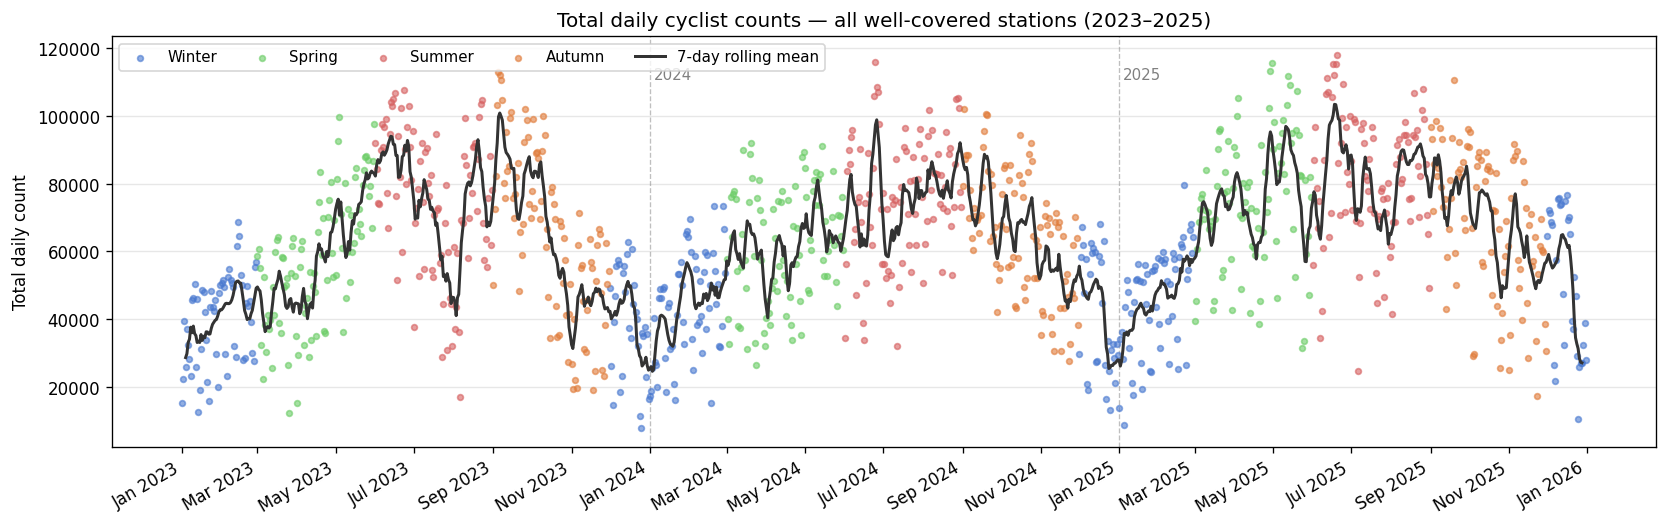

Mean total daily count by season:
season
summer    77469.0
autumn    66254.0
spring    64574.0
winter    43328.0
Name: total, dtype: float32


In [9]:
# ── total daily count across well-covered stations, coloured by season ────────
daily_sum = (
    daily[~daily["low_coverage"]]
    .groupby("date")["aantal"]
    .sum(min_count=1)
    .reset_index(name="total")
)
daily_sum["season"] = daily_sum["date"].dt.month.map(SEASON_MAP)
daily_sum["roll7"]  = daily_sum["total"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4.5))

# scatter coloured by season
for season, color in SEASON_COLORS.items():
    mask = daily_sum["season"] == season
    ax.scatter(daily_sum.loc[mask, "date"], daily_sum.loc[mask, "total"],
               color=color, s=12, alpha=0.6, label=season.capitalize(), zorder=3)

# 7-day rolling mean in dark grey
ax.plot(daily_sum["date"], daily_sum["roll7"],
        color="#333", lw=1.8, label="7-day rolling mean", zorder=4)

# year boundaries
for yr in ["2024-01-01", "2025-01-01"]:
    ax.axvline(pd.Timestamp(yr), color="grey", lw=0.8, ls="--", alpha=0.5)
    ax.text(pd.Timestamp(yr) + pd.Timedelta(days=3),
            daily_sum["total"].max() * 0.97,
            yr[:4], fontsize=9, color="grey", va="top")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
ax.set_title("Total daily cyclist counts — all well-covered stations (2023–2025)",
             fontsize=12)
ax.set_ylabel("Total daily count")
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig05_daily_totals_2023_2025.png", dpi=150)
plt.show()

# quick seasonal means
print("Mean total daily count by season:")
print(daily_sum.groupby("season")["total"].mean().sort_values(ascending=False).round(0))